In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold0_with_positions_steps_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold1_with_positions_steps_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold2_with_positions_steps_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
len(df)

164

In [8]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [11]:
# selecting only sequences with a measurable contact enrichment
df = df[df['URQ_delta'] > 0.0]

In [12]:
len(df)

158

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'ctcf_motif_locs',
       'last_accepted_step', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'positions',
       'URQ_delta'],
      dtype='object')

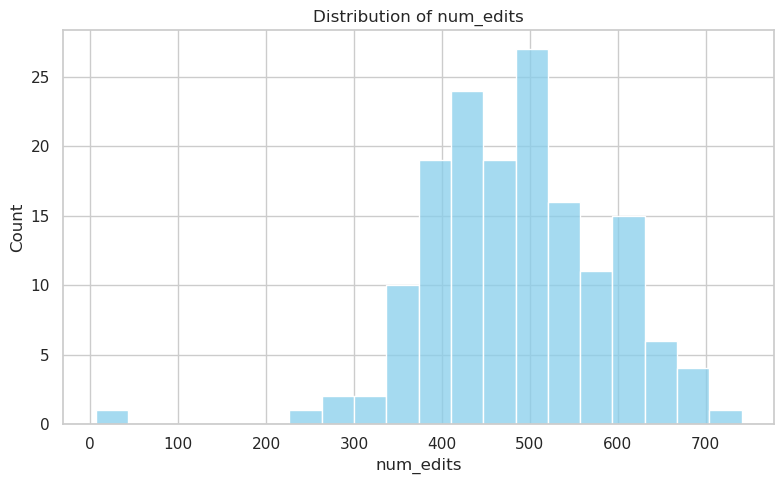

In [17]:
# Set style
sns.set(style="whitegrid")

# Plot histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['num_edits'], kde=False, bins=20, color='skyblue')
plt.title('Distribution of num_edits')
plt.xlabel('num_edits')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [18]:
from scipy.stats import ttest_rel

In [19]:
t_stat, p_value = ttest_rel(df['URQ_result'], df['URQ_init'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = 40.976, p = 9.691e-86


/tmp/SLURM_1442649/ipykernel_1717173/914426728.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metric', y='Value', data=df_melted, palette='Set2')


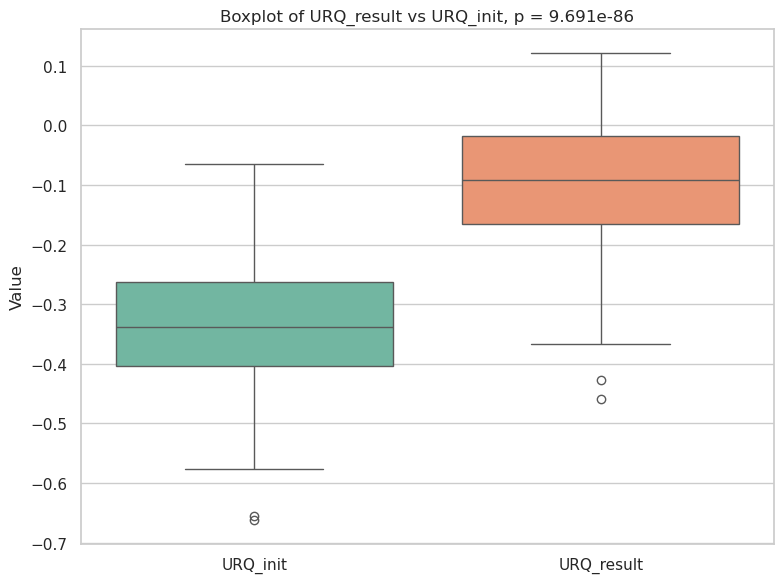

In [21]:
df_melted = df[['URQ_init', 'URQ_result']].melt(var_name='Metric', value_name='Value')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Metric', y='Value', data=df_melted, palette='Set2')
plt.title(f'Boxplot of URQ_result vs URQ_init, p = {p_value:.3e}')
plt.ylabel('Value')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [25]:
t_stat, p_value = ttest_rel(df['init_CTCFs_num'], df['CTCFs_num'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = -22.233, p = 2.284e-50


/tmp/SLURM_1442649/ipykernel_1717173/2071884761.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metric', y='Value', data=df_melted, palette='Set2')


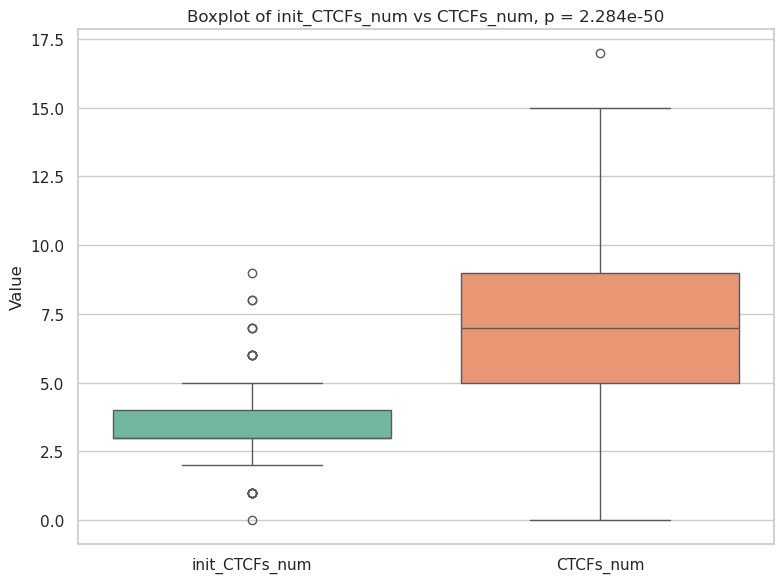

In [26]:
df_melted = df[['init_CTCFs_num', 'CTCFs_num']].melt(var_name='Metric', value_name='Value')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Metric', y='Value', data=df_melted, palette='Set2')
plt.title(f'Boxplot of init_CTCFs_num vs CTCFs_num, p = {p_value:.3e}')
plt.ylabel('Value')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [22]:
t_stat, p_value = ttest_rel(df['GC_slice'], df['GC_slice_edited'])
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_value:.3e}")

Paired t-test: t = -22.321, p = 1.423e-50


/tmp/SLURM_1442649/ipykernel_1717173/1938061034.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')


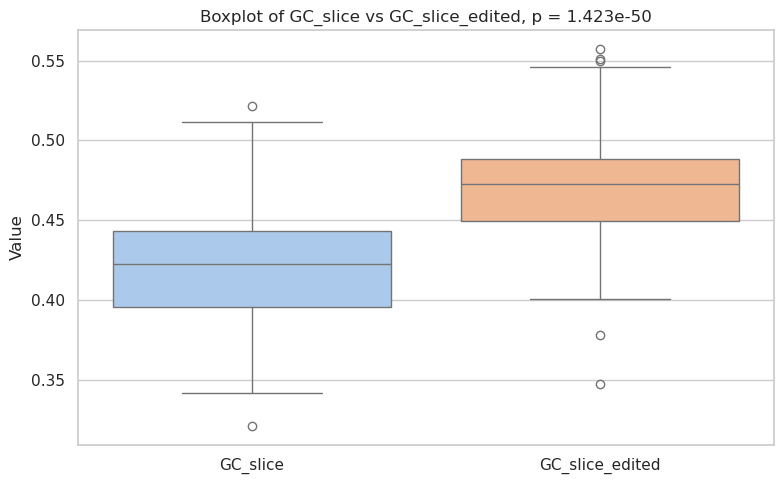

In [23]:
# Reshape for seaborn boxplot
df_melted = df[['GC_slice', 'GC_slice_edited']].melt(var_name='Condition', value_name='Value')

plt.figure(figsize=(8, 5))
sns.boxplot(x='Condition', y='Value', data=df_melted, palette='pastel')
plt.title(f'Boxplot of GC_slice vs GC_slice_edited, p = {p_value:.3e}')
plt.xlabel('')
plt.ylabel('Value')
plt.tight_layout()
plt.show()